# Netflix Stock Price Prediction ML Project

#### Mohamed Youssef Abdelnasser - 211001821


## Index

[Including Necessary Libraries](#libs)
<br>
[Data Preprocessing](#dataset)
<br>
[Data Visualization](#vis)
<br>
[Random Forest Model](#m1)
<br>
[Polynomial Regression Model](#m2)
<br>
[Ada Boost Model](#m3)
<br>
[Model Comparison](#compare)


## Including Necessary Libraries <a id='libs'></a>


In [1]:
# Python built-in libraries
import datetime as dt
import time
import warnings

# Libraries for preprocessing and visualizing the data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ML models evaluation metrics
from sklearn import metrics

# Sklearn ML models classes
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import AdaBoostRegressor

In [2]:
# Disabling warnings
def warn(*args, **kwargs):
    pass


warnings.warn = warn

## Data Preprocessing <a id='dataset'></a>


### Data Gathering

The data set that will be used is collected from finance.yahoo, the collected data spans from January 2nd, 2018,
<br>till December 30th, 2022, with about a daily step interval


In [3]:
# Importing the dataset csv file
NFLX_df = pd.read_csv("./data/NFLX.csv")

NFLX_df.sample(10)  # Showing 10 random records

,Date,Open,High,Low,Close,Adj Close,Volume
250,2018-12-31,260.160004,270.100006,260.000000,267.660004,267.660004,13508900
645,2020-07-27,484.510010,496.920013,482.309998,495.649994,495.649994,7863100
580,2020-04-23,419.260010,438.410004,419.260010,426.700012,426.700012,13952300
435,2019-09-25,255.710007,266.600006,253.699997,264.750000,264.750000,11643800
976,2021-11-16,678.270020,688.359985,676.900024,687.400024,687.400024,2077400
216,2018-11-08,328.000000,332.049988,316.609985,317.920013,317.920013,11023900
622,2020-06-23,466.500000,474.010010,464.500000,466.260010,466.260010,5948400
1235,2022-11-28,284.000000,289.549988,280.529999,281.170013,281.170013,4703400
1241,2022-12-06,311.000000,313.220001,303.130005,305.559998,305.559998,7195400
14,2018-01-23,255.050003,257.709991,248.020004,250.289993,250.289993,27705300


### Attributes Description


Open: the price from the first transaction of a business day.
<br>
High: the highest price at which a stock is traded during the business day.
<br>
Low: the lowest price at which a stock is traded during the business day.
<br>
Close: the last price anyone paid for a share of stock during a business day.
<br>
Adj Close: the closing price after adjustments for all applicable splits and dividend distributions.
<br>
Volume: the number of shares traded in a stock or contracts traded in futures or options (indicates market strength).
<br>
<br>
All of the prices are in USD


### Statistical Analysis

In [4]:
# Generating descriptive statistics
NFLX_df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,1259.000000,1259.000000,1259.000000,1259.000000,1259.000000,1.259000e+03
mean,387.752923,393.907275,381.288920,387.752430,387.752430,8.204729e+06
std,119.680365,120.384675,118.574058,119.378060,119.378060,6.860656e+06
min,163.960007,172.059998,162.710007,166.369995,166.369995,1.144000e+06
25%,298.714996,303.549988,292.399994,298.550003,298.550003,4.400600e+06
50%,361.959991,367.329987,356.619995,361.809998,361.809998,6.525600e+06
75%,495.000000,502.895004,487.770005,494.455002,494.455002,9.915100e+06
max,692.349976,700.989990,686.090027,691.690002,691.690002,1.333875e+08


### Data Cleaning

In [5]:
# Setting the data feature as the index
NFLX_df.set_index("Date", inplace=True, drop=False)

# Converting the data column to days since the epoch
NFLX_df["Date"] = pd.to_datetime(NFLX_df["Date"])
NFLX_df["Date"] = (NFLX_df["Date"] - pd.Timestamp("1970-01-01")) / pd.Timedelta(days=1)

print(
    "Number of records where the 'Close' column values is equal to the 'Adj Close' column values",
    NFLX_df[NFLX_df["Close"] == NFLX_df["Adj Close"]].shape[0],
)
print("Number of total records", NFLX_df.shape[0])

# Since the 'Close' column values is always equal to the 'Adj Close' column values we will drop the 'Adj Close' column
NFLX_df.__delitem__("Adj Close")

# Also the 'Volume' column won't be needed since it doesn't describe the NFLX stock it describes the market
NFLX_df.__delitem__("Volume")

# Dividing the dataset to X and y while ignoring both volume and adj close features
X = NFLX_df[["Open", "High", "Low"]]
y = NFLX_df[["Close"]]

# Dividing the X and y values to training and testing values (80-20 % Cut)
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y.values, test_size=0.2, random_state=1
)

Number of records where the 'Close' column values is equal to the 'Adj Close' column values 1259
Number of total records 1259


In [6]:
# Checking for null values
NFLX_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1259 entries, 2018-01-02 to 2022-12-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1259 non-null   float64
 1   Open    1259 non-null   float64
 2   High    1259 non-null   float64
 3   Low     1259 non-null   float64
 4   Close   1259 non-null   float64
dtypes: float64(5)
memory usage: 91.3+ KB


In [7]:
# The dataset after the cleaning
NFLX_df.sample(10)

,Date,Open,High,Low,Close
Date,,,,,
2020-12-21,18617.0,530.049988,532.619995,521.150024,528.909973
2019-04-30,18016.0,369.559998,374.500000,368.350006,370.540009
2021-12-28,18989.0,614.950012,618.409973,609.690002,610.710022
2019-09-26,18165.0,266.420013,268.049988,260.200012,263.309998
2021-10-28,18928.0,670.950012,676.799988,668.030029,674.049988
2019-12-04,18234.0,308.429993,308.429993,303.269989,304.320007
2019-07-09,18086.0,379.059998,384.760010,377.500000,379.929993
2018-06-12,17694.0,363.600006,365.980011,362.000000,363.829987
2019-06-11,18058.0,355.000000,357.579987,348.500000,351.269989


## Data Visualization <a id='vis'></a>

### Univariate Exploration

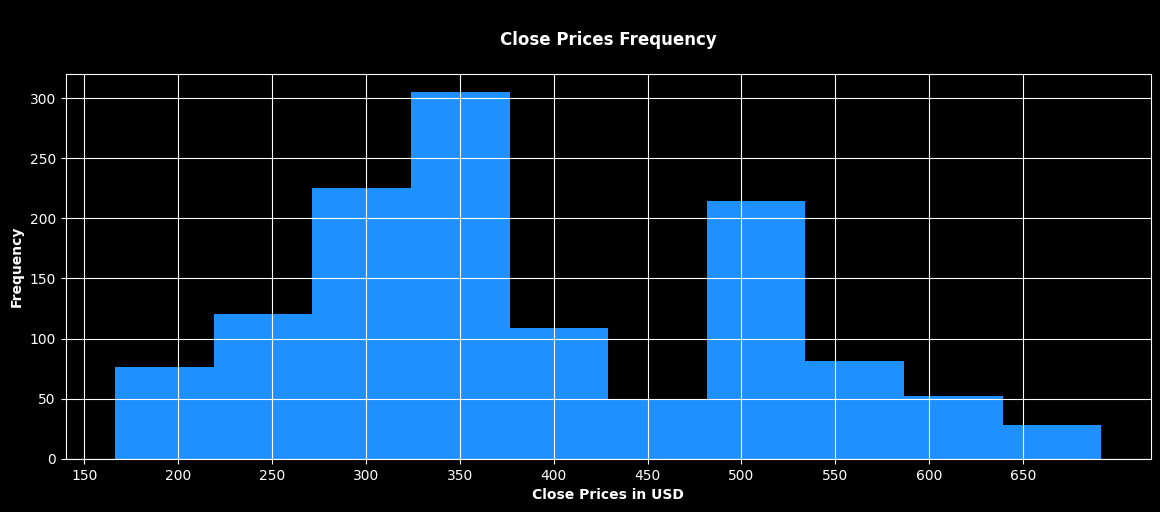

In [8]:
# Visualizing the datasets closing prices frequency
plt.figure(figsize=(14, 5))
plt.hist(NFLX_df["Close"], color="dodgerblue")
plt.xlabel("Close Prices in USD", weight="bold")
plt.ylabel("Frequency", weight="bold")
plt.title("\nClose Prices Frequency\n", weight="bold")
plt.xticks(np.arange(150, 700, 50))
plt.yticks(np.arange(0, 350, 50))
plt.grid()
plt.show()

### Bivariate Exploration

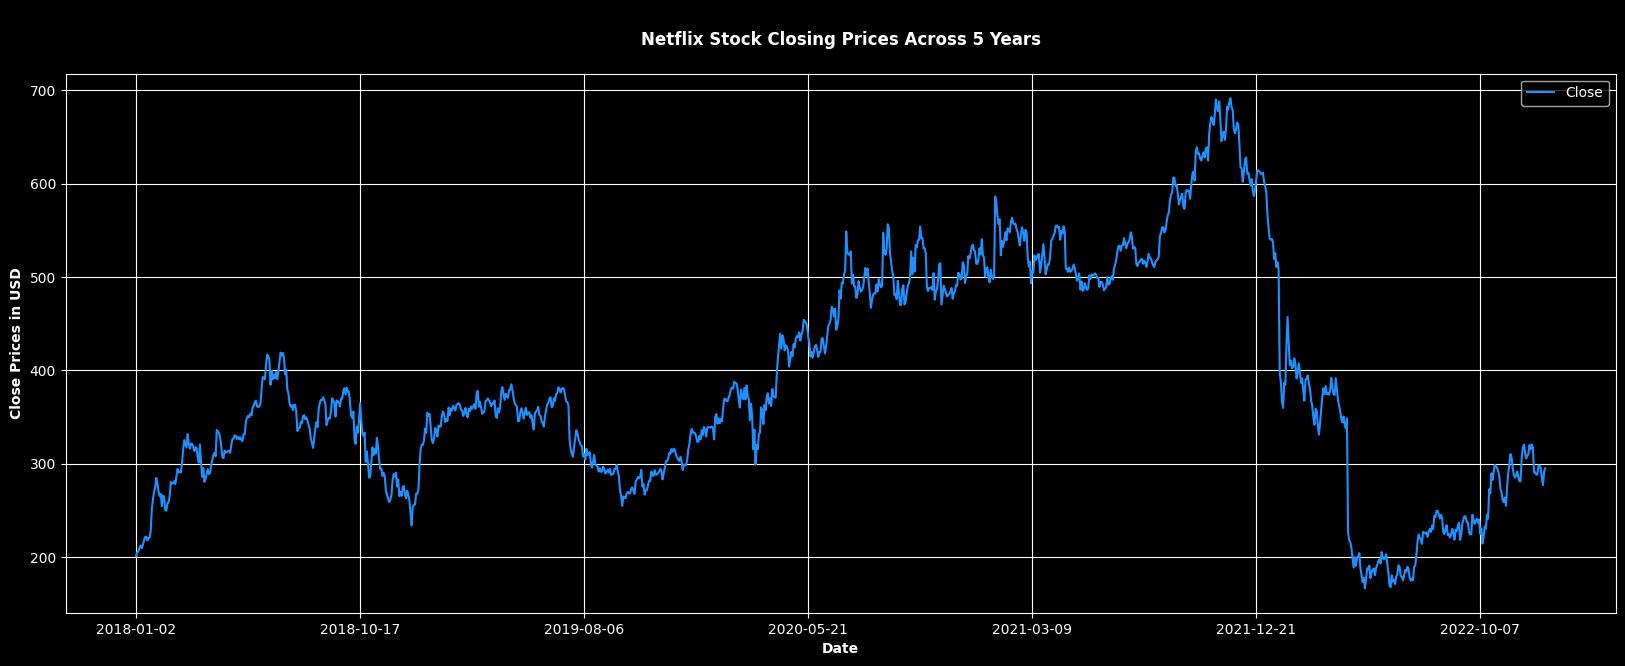

In [9]:
# Plotting the datasets closing prices against the index (Date)
NFLX_df["Close"].plot(color="dodgerblue", figsize=(20, 7))
plt.ylabel("Close Prices in USD", weight="bold")
plt.xlabel("Date", weight="bold")
plt.title("\nNetflix Stock Closing Prices Across 5 Years\n", weight="bold")
plt.grid()
plt.legend()
plt.show()

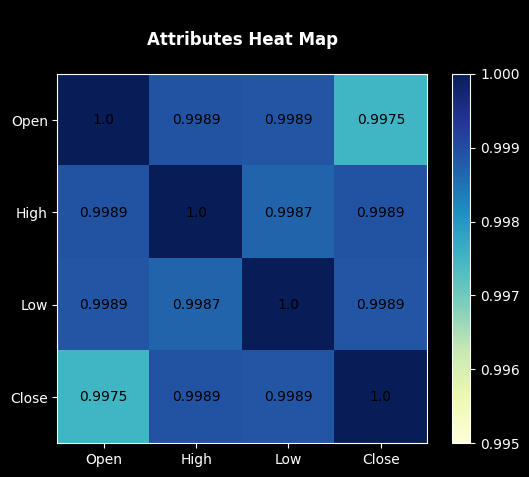

In [10]:
# Visualizing the correlation matrix through a heat map
corr = NFLX_df[["Open", "High", "Low", "Close"]].corr()
plt.imshow(corr, cmap="YlGnBu", interpolation="nearest", vmin=0.995)
plt.colorbar()

for i in range(4):
    for j in range(4):
        plt.annotate(
            str(round(corr.values[i][j], 4)),
            xy=(j, i),
            ha="center",
            va="center",
            color="black",
        )

plt.title("\nAttributes Heat Map\n", weight="bold")
plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show()

## Random Forest Regression<a id='m1'></a>

### Random Search Cross Validation

Random Search CV is a technique used in hyper-tuning the parameters, like Grid Search CV it uses k-fold as CV, but unlike it doesn't
<br> brute force its way across the hyper parameters but selects hyper parameter combination at random

In [11]:
# Hyper-Tuning the random forest regression model using randomized search cross validation
rfr = RandomForestRegressor()

# Initializing the parameter grid
rfrg = {
    "n_estimators": [20, 50, 100, 500, 1000],
    "max_depth": np.arange(1, 15, 1),
    "min_samples_split": np.arange(2, 10, 2),
    "min_samples_leaf": np.arange(1, 15, 2),
    "bootstrap": [True, False],
    "random_state": [1],
}

# Initializing the randomized search CV
rscv = RandomizedSearchCV(
    estimator=rfr,
    param_distributions=rfrg,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=100,
    n_iter=200,
    return_train_score=True,
    random_state=1,
)

rfr_start_time = time.time()

# Fitting the randomized search CV
rscv.fit(X_train, y_train.ravel())

rfr_elapsed_time = time.time() - rfr_start_time

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
[CV 1/5; 1/200] START bootstrap=True, max_depth=3, min_samples_leaf=7, min_samples_split=4, n_estimators=20, random_state=1
[CV 2/5; 1/200] START bootstrap=True, max_depth=3, min_samples_leaf=7, min_samples_split=4, n_estimators=20, random_state=1
[CV 1/5; 1/200] END bootstrap=True, max_depth=3, min_samples_leaf=7, min_samples_split=4, n_estimators=20, random_state=1;, score=(train=-167.188, test=-164.520) total time=   0.1s
[CV 2/5; 1/200] END bootstrap=True, max_depth=3, min_samples_leaf=7, min_samples_split=4, n_estimators=20, random_state=1;, score=(train=-144.756, test=-154.883) total time=   0.1s
[CV 2/5; 4/200] START bootstrap=False, max_depth=12, min_samples_leaf=11, min_samples_split=4, n_estimators=500, random_state=1
[CV 3/5; 1/200] START bootstrap=True, max_depth=3, min_samples_leaf=7, min_samples_split=4, n_estimators=20, random_state=1
[CV 3/5; 4/200] START bootstrap=False, max_depth=12, min_samples_leaf=11, 

In [12]:
# Obtaining the parameter values for every MSE, while also finding the best one
best_parameters = rscv.best_params_
rscv_results = rscv.cv_results_

for mean_score, parameters in zip(
    tuple(rscv_results["mean_test_score"]), tuple(rscv_results["params"])
):
    if parameters == best_parameters:
        print("Best MSE", "\t", "Best Parameters")
        print(round(-mean_score, 2), "\t\t", parameters)


print("\nMSE", "\t\t", "Parameters")
for mean_score, parameters in zip(
    tuple(rscv_results["mean_test_score"]), tuple(rscv_results["params"])
):
    print(round(-mean_score, 2), "\t\t", parameters)

Best MSE 	 Best Parameters
26.39 		 {'random_state': 1, 'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 9, 'bootstrap': True}

MSE 		 Parameters
186.84 		 {'random_state': 1, 'n_estimators': 20, 'min_samples_split': 4, 'min_samples_leaf': 7, 'max_depth': 3, 'bootstrap': True}
115.32 		 {'random_state': 1, 'n_estimators': 20, 'min_samples_split': 6, 'min_samples_leaf': 5, 'max_depth': 4, 'bootstrap': False}
36.28 		 {'random_state': 1, 'n_estimators': 50, 'min_samples_split': 4, 'min_samples_leaf': 9, 'max_depth': 9, 'bootstrap': True}
46.18 		 {'random_state': 1, 'n_estimators': 500, 'min_samples_split': 4, 'min_samples_leaf': 11, 'max_depth': 12, 'bootstrap': False}
65.8 		 {'random_state': 1, 'n_estimators': 100, 'min_samples_split': 8, 'min_samples_leaf': 13, 'max_depth': 4, 'bootstrap': True}
3378.46 		 {'random_state': 1, 'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 11, 'max_depth': 1, 'bootstrap': True}
31.82 		 {'random_state'

### Model Fitting

Random Forest Model is a supervised, ensemble, regression ML model which basically combines the output of more than one model, in this case
<br> the random forest combines decision trees then selects the outcome based on either the majority (in the case of classification) or mean 
<br> (in the case of regression) which is the case here.

In [13]:
# Initializing the random forest model with the best parameters
rfr_best = rscv.best_estimator_

rfr_best.fit(X_train, y_train.ravel())  # Fitting the final model

y_rfr_predict = rfr_best.predict(X_test)  # Predicting the testing values

### Performance Evaluation


The performance evaluation metrics that will be used for all the models in the notebook are:
<br>
<br>
MSE (Mean Squared Error): Which is the most common evaluation metrics for regression problems
<br>
MAPE (Mean Absolute Percentage Error): Which is common in stock prediction model in %
<br>
Scores (Both training and Testing): The coefficient of determination of the prediction in %
<br>
Total Computational Time: The total time took to fit the model in seconds

In [14]:
# Calculating the evaluation metrics
rfr_MSE = round(metrics.mean_squared_error(y_test, y_rfr_predict), 4)
rfr_MAPE = 100 - round(np.mean(np.abs((y_test - y_rfr_predict) / y_test)), 4)
rfr_total_time = round(rfr_elapsed_time, 4)

print("Random Forest with Random Search CV Evaluation Metrics:\n")
print("MSE:", rfr_MSE)
print("MAPE:", rfr_MAPE, "%")
print("Training Score:", round(rfr_best.score(X_train, y_train) * 100, 4), "%")
print("Testing Score:", round(rfr_best.score(X_test, y_test) * 100, 4), "%")
print("Total Computational Time on 16 Parallel Processors", rfr_total_time, "s")

Random Forest with Random Search CV Evaluation Metrics:

MSE: 22.6661
MAPE: 99.6208 %
Training Score: 99.9654 %
Testing Score: 99.8493 %
Total Computational Time on 16 Parallel Processors 83.1717 s


In [15]:
# Adding the random forest close prediction column to the original dataframe
NFLX_df["RFR Close Predictions"] = rfr_best.predict(
    NFLX_df[["Open", "High", "Low"]].values
)
NFLX_df.sample(10)

,Date,Open,High,Low,Close,RFR Close Predictions
Date,,,,,,
2021-12-15,18976.0,598.179993,605.690002,584.510010,605.039978,600.673001
2019-05-20,18036.0,351.230011,352.420013,345.399994,348.109985,348.068053
2021-03-22,18708.0,509.130005,529.309998,509.130005,523.109985,522.129888
2020-09-08,18513.0,498.399994,522.000000,495.000000,507.019989,509.776401
2018-05-01,17652.0,310.359985,313.480011,306.690002,313.299988,311.488611
2019-12-23,18253.0,337.760010,337.950012,331.019989,333.100006,333.109246
2020-04-03,18355.0,367.470001,370.899994,357.510010,361.760010,362.977601
2021-06-21,18799.0,501.640015,502.049988,492.279999,497.000000,497.840886
2022-09-09,19244.0,229.619995,234.779999,229.619995,233.570007,233.252234


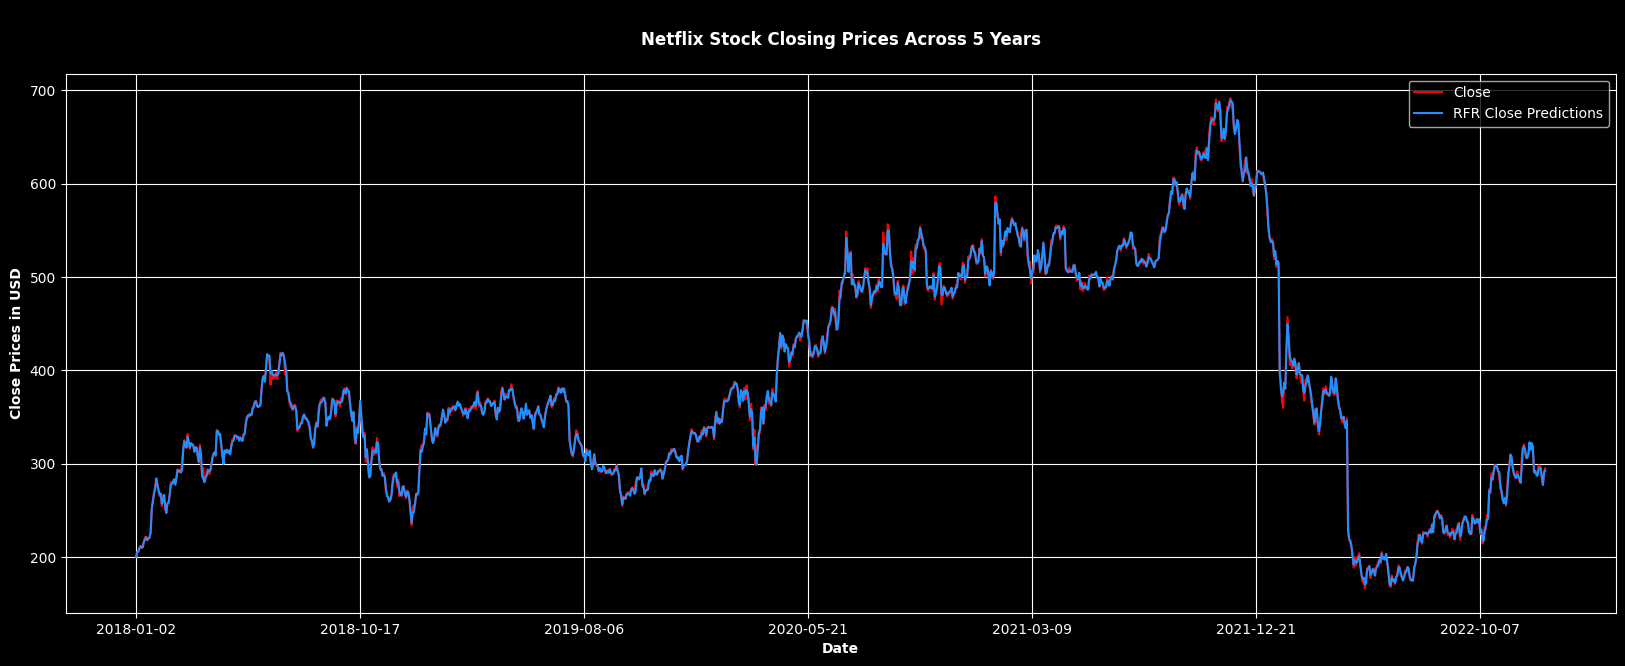

In [16]:
# Plotting the predictions and the datasets closing prices against the index (Date)
NFLX_df["Close"].plot(color="red", figsize=(20, 7))
NFLX_df["RFR Close Predictions"].plot(color="dodgerblue")

plt.xlabel("Date", weight="bold")
plt.ylabel("Close Prices in USD", weight="bold")
plt.title("\nNetflix Stock Closing Prices Across 5 Years\n", weight="bold")
plt.legend()
plt.grid()
plt.show()

## Polynomial Regression<a id='m2'></a>

### Elastic net regularization

Elastic Net regularization is a technique used in machine learning to prevent overfitting and improve the generalization of a model by limiting the
</br> model parameters, it combines two types of regularization: L1 regularization (Lasso) and L2 regularization (Ridge).

In [17]:
# Obtaining the best degree for the elastic net regularized polynomial regression model using randomized search cross validation
elastic_net = ElasticNet(alpha=1.0, l1_ratio=0.5)
poly_MSE_list = []

print("Degree", "\t\t", "MSE")

poly_start_time = time.time()

for deg in range(1, 10):
    # Initializing the model with iterated degree
    poly = PolynomialFeatures(degree=deg)

    # Transforming the X values into a polynomial feature space (Polynomial Equation)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    elastic_net.fit(
        X_train_poly, y_train
    )  # Fitting the model elastic net regularized polynomial regression

    y_poly_predict = elastic_net.predict(X_test_poly)  # Predicting the testing values

    poly_MSE_list.append(round(metrics.mean_squared_error(y_test, y_poly_predict), 4))

    print(deg, "\t\t", poly_MSE_list[deg - 1])

poly_elapsed_time = time.time() - poly_start_time

best_degree = poly_MSE_list.index(min(poly_MSE_list)) + 1

print("\nBest Degree", "\t", "MSE")
print(best_degree, "\t\t", min(poly_MSE_list))

Degree 		 MSE
1 		 15.4166
2 		 15.7544
3 		 18.973
4 		 21.3576
5 		 21.7039
6 		 20.5722
7 		 19.2818
8 		 18.6823
9 		 18.8583

Best Degree 	 MSE
1 		 15.4166


### Model Fitting

Polynomial regression is a supervised, regression ML Model where the relationship between the independent variable and the dependent variable is modeled as an
</br> nth-degree polynomial. It allows for nonlinear relationships between the variables by fitting a curve to the data points, capturing more 
</br> complex patterns than traditional linear regression.

In [18]:
# Initializing the polynomial regression model with the best degree
elastic_net_best = ElasticNet(alpha=1.0, l1_ratio=0.5)
poly_best = PolynomialFeatures(degree=best_degree)

# Fitting the final model
X_train_poly_best = poly_best.fit_transform(X_train)
elastic_net_best.fit(X_train_poly_best, y_train)

# Predicting the testing values
X_test_poly_best = poly_best.transform(X_test)
y_poly_predict = elastic_net_best.predict(X_test_poly_best)

### Performance Evaluation

In [19]:
# Calculating the evaluation metrics
poly_MSE = round(metrics.mean_squared_error(y_test, y_poly_predict), 4)
poly_MAPE = 100 - round(np.mean(np.abs((y_test - y_poly_predict) / y_test)), 4)
poly_total_time = round(poly_elapsed_time, 4)

print("Polynomial Regression with elastic net regularization Evaluation Metrics:\n")
print("MSE:", poly_MSE)
print("MAPE:", poly_MAPE, "%")
print(
    "Training Score:",
    round(elastic_net_best.score(X_train_poly_best, y_train) * 100, 4),
    "%",
)
print(
    "Testing Score:",
    round(elastic_net_best.score(X_test_poly_best, y_test) * 100, 4),
    "%",
)
print("Total Computational Time", poly_total_time, "s")

Polynomial Regression with elastic net regularization Evaluation Metrics:

MSE: 15.4166
MAPE: 99.6214 %
Training Score: 99.8829 %
Testing Score: 99.8975 %
Total Computational Time 0.506 s


In [20]:
# Adding the polynomial regression close prediction column to the original dataframe
NFLX_df["Polynomial Close Predictions"] = elastic_net_best.predict(
    poly_best.transform(NFLX_df[["Open", "High", "Low"]])
)
NFLX_df.sample(10)

,Date,Open,High,Low,Close,RFR Close Predictions,Polynomial Close Predictions
Date,,,,,,,
2020-11-12,18578.0,491.000000,496.519989,480.429993,486.769989,488.616837,488.029105
2019-01-18,17914.0,351.970001,353.000000,336.730011,339.100006,339.550973,343.176121
2022-05-05,19117.0,200.449997,200.710007,186.000000,188.320007,191.512267,191.854737
2019-02-01,17928.0,337.179993,346.839996,336.500000,339.850006,342.116470,343.304874
2021-07-16,18824.0,541.809998,544.059998,527.049988,530.309998,534.487918,533.750547
2021-06-02,18780.0,499.820007,503.220001,495.820007,499.239990,499.994038,498.474135
2018-10-18,17822.0,360.670013,362.200012,346.049988,346.709991,353.261671,352.596228
2019-05-07,18023.0,377.000000,379.910004,365.809998,370.459991,371.603763,371.834328
2018-08-24,17767.0,346.000000,359.149994,344.540009,358.820007,353.382822,354.629598


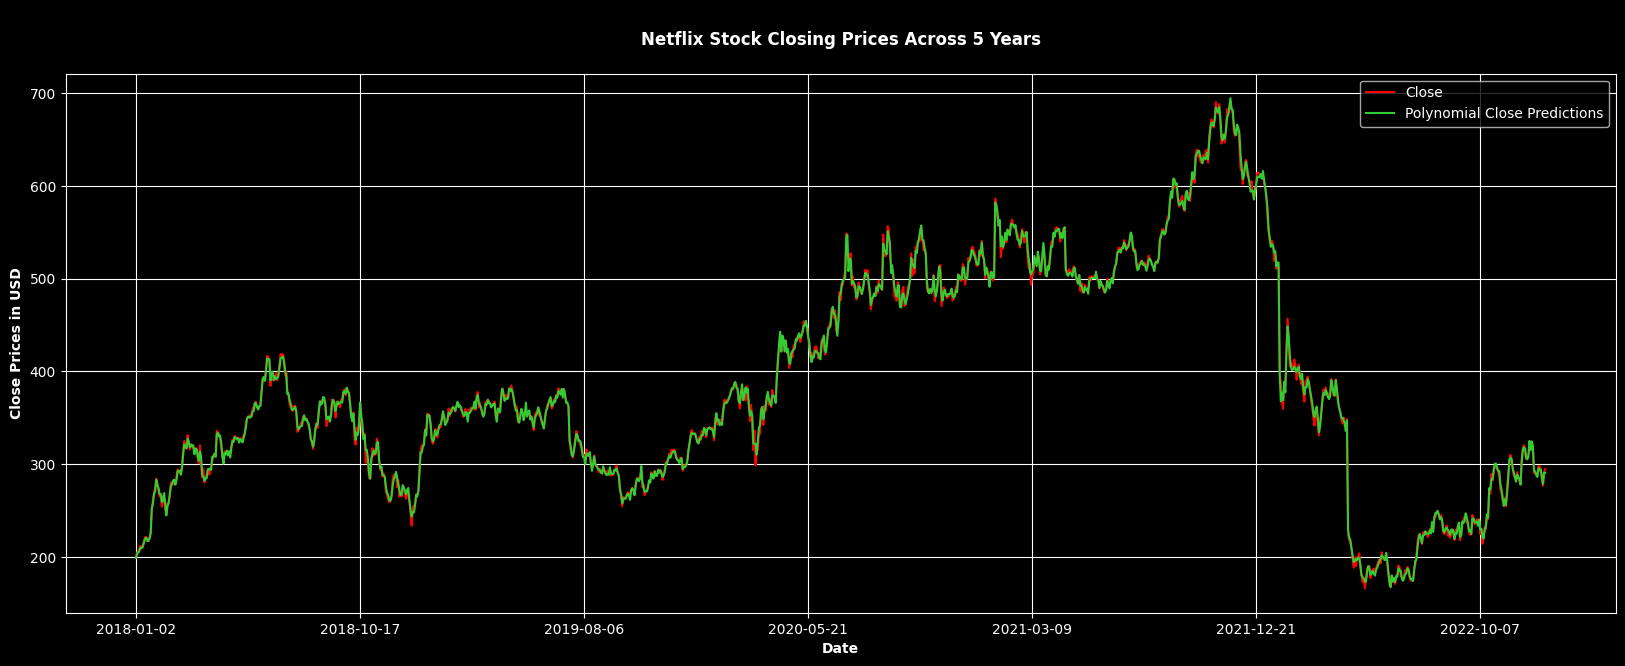

In [21]:
# Plotting the predictions and the datasets closing prices against the index (Date)
NFLX_df["Close"].plot(color="red", figsize=(20, 7))
NFLX_df["Polynomial Close Predictions"].plot(color="limegreen")

plt.xlabel("Date", weight="bold")
plt.ylabel("Close Prices in USD", weight="bold")
plt.title("\nNetflix Stock Closing Prices Across 5 Years\n", weight="bold")
plt.legend()
plt.grid()
plt.show()

## Ada Boost<a id='m3'></a>

### Model Fitting

AdaBoost, short for Adaptive Boosting, is a supervised, ensemble, regression ML model that combines multiple "weak" models to create a "strong" model.
</br> It does this by sequentially training the weak learners on different versions of the data, with each subsequent weak learner focusing more on
</br> the samples that were misclassified by the previous learners.

In [22]:
# Initializing the ada boost model with the best random forest parameters as the estimator
ada_boost = AdaBoostRegressor(estimator=rfr_best, n_estimators=50, random_state=1)

ada_start_time = time.time()

ada_boost.fit(X_train, y_train)  # Fitting the final model

ada_elapsed_time = time.time() - ada_start_time

y_ada_predict = ada_boost.predict(X_test)  # Predicting the testing values

### Performance Evaluation

In [23]:
# Calculating the evaluation metrics
ada_MSE = round(metrics.mean_squared_error(y_test, y_ada_predict), 4)
ada_MAPE = 100 - round(np.mean(np.abs((y_test - y_ada_predict) / y_test)), 4)
ada_total_time = round(ada_elapsed_time, 4)

print(
    "Ada Boost with the best random forest parameters as the estimator Evaluation Metrics:\n"
)
print("MSE:", ada_MSE)
print("MAPE:", ada_MAPE, "%")
print("Training Score:", round(ada_boost.score(X_train, y_train) * 100, 4), "%")
print("Testing Score:", round(ada_boost.score(X_test, y_test) * 100, 4), "%")
print("Total Computational Time", ada_total_time, "s")

Ada Boost with the best random forest parameters as the estimator Evaluation Metrics:

MSE: 22.4791
MAPE: 99.6207 %
Training Score: 99.9817 %
Testing Score: 99.8505 %
Total Computational Time 46.6606 s


In [24]:
# Adding the Ada Boost close prediction column to the original dataframe
NFLX_df["Ada Close Predictions"] = ada_boost.predict(NFLX_df[["Open", "High", "Low"]])
NFLX_df.sample(10)

,Date,Open,High,Low,Close,RFR Close Predictions,Polynomial Close Predictions,Ada Close Predictions
Date,,,,,,,,
2020-04-01,18353.0,376.049988,380.230011,361.019989,364.079987,368.672960,369.948536,365.850426
2021-03-29,18715.0,505.660004,518.000000,504.399994,513.950012,512.864549,513.255262,512.776644
2021-02-19,18677.0,548.000000,548.989990,538.809998,540.219971,542.095632,541.774205,542.756260
2020-05-04,18386.0,417.779999,428.540009,414.869995,428.149994,426.587629,423.434238,427.253246
2018-06-19,17701.0,389.500000,405.290009,388.500000,404.980011,401.340567,400.467825,403.538364
2021-03-02,18688.0,553.340027,556.989990,546.020020,547.820007,550.665322,550.315653,550.073477
2019-06-04,18051.0,345.000000,353.609985,343.250000,353.399994,351.307006,349.659225,351.570907
2020-12-11,18607.0,495.000000,503.339996,494.850006,503.220001,500.817301,499.839035,500.794832
2022-11-28,19324.0,284.000000,289.549988,280.529999,281.170013,283.958453,285.358835,283.406615


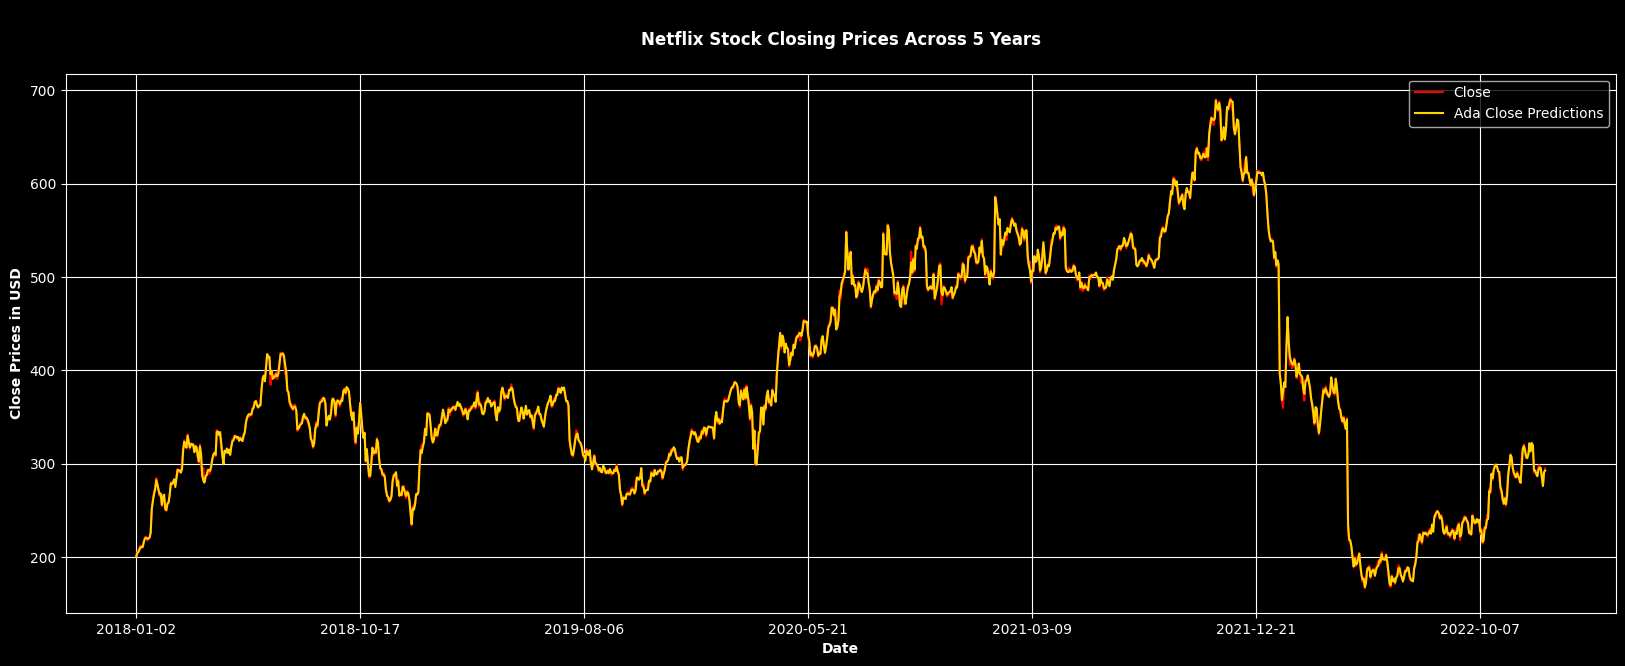

In [25]:
# Plotting the predictions and the datasets closing prices against the index (Date)
NFLX_df["Close"].plot(color="red", figsize=(20, 7))
NFLX_df["Ada Close Predictions"].plot(color="gold")

plt.xlabel("Date", weight="bold")
plt.ylabel("Close Prices in USD", weight="bold")
plt.title("\nNetflix Stock Closing Prices Across 5 Years\n", weight="bold")
plt.legend()
plt.grid()
plt.show()

## Model Comparison<a id='compare'></a>

In [26]:
# Initializing a nested dictionary with all the evaluation metrics values
all_metrics = {
    "MSE": {"Random Forest": rfr_MSE, "Polynomial": poly_MSE, "Ada boost": ada_MSE},
    "MAPE": {"Random Forest": rfr_MAPE, "Polynomial": poly_MAPE, "Ada boost": ada_MAPE},
    "Total Time": {
        "Random Forest": rfr_total_time,
        "Polynomial": poly_total_time,
        "Ada boost": ada_total_time,
    },
}

In [27]:
# Getting the minimum and the maximum MSE
min_MSE = min(all_metrics["MSE"].values())
min_MSE_model = [i for i in all_metrics["MSE"] if all_metrics["MSE"][i] == min_MSE][0]
print("The regression model with the least MSE is", min_MSE_model, "which is:", min_MSE)

max_MSE = max(all_metrics["MSE"].values())
max_MSE_model = [i for i in all_metrics["MSE"] if all_metrics["MSE"][i] == max_MSE][0]
print("The regression model with the most MSE is", max_MSE_model, "which is:", max_MSE)

The regression model with the least MSE is Polynomial which is: 15.4166
The regression model with the most MSE is Random Forest which is: 22.6661


In [28]:
# Getting the minimum and the maximum MAPE
min_MAPE = min(all_metrics["MAPE"].values())
min_MAPE_model = [i for i in all_metrics["MAPE"] if all_metrics["MAPE"][i] == min_MAPE][
    0
]
print(
    "The regression model with the least MAPE is",
    min_MAPE_model,
    "which is:",
    min_MAPE,
    "%",
)

max_MAPE = max(all_metrics["MAPE"].values())
max_MAPE_model = [i for i in all_metrics["MAPE"] if all_metrics["MAPE"][i] == max_MAPE][
    0
]
print(
    "The regression model with the most MAPE is",
    max_MAPE_model,
    "which is:",
    max_MAPE,
    "%",
)

The regression model with the least MAPE is Ada boost which is: 99.6207 %
The regression model with the most MAPE is Polynomial which is: 99.6214 %


In [29]:
# Getting the minimum and the maximum computational time
min_time = min(all_metrics["Total Time"].values())
min_time_model = [
    i for i in all_metrics["Total Time"] if all_metrics["Total Time"][i] == min_time
][0]
print(
    "The regression model with the least computational time is",
    min_time_model,
    "which is:",
    min_time,
    "s",
)

max_time = max(all_metrics["Total Time"].values())
max_time_model = [
    i for i in all_metrics["Total Time"] if all_metrics["Total Time"][i] == max_time
][0]
print(
    "The regression model with the most computational time is",
    max_time_model,
    "which is:",
    max_time,
    "s",
)

The regression model with the least computational time is Polynomial which is: 0.506 s
The regression model with the most computational time is Random Forest which is: 83.1717 s


In [30]:
# Showing the final dataframe with all the models results
NFLX_df.to_csv("./data/NFLX_Final.csv")
NFLX_df.sample(10)

,Date,Open,High,Low,Close,RFR Close Predictions,Polynomial Close Predictions,Ada Close Predictions
Date,,,,,,,,
2018-06-20,17702.0,415.149994,419.470001,409.600006,416.760010,417.358932,414.010607,417.374496
2018-03-05,17595.0,302.850006,316.910004,297.600006,315.000000,313.348560,310.387717,314.299873
2019-04-23,18009.0,375.450012,384.799988,374.709991,381.890015,380.363626,381.172984,381.212367
2021-11-30,18961.0,668.200012,675.380005,640.010010,641.900024,644.933259,656.907414,642.908259
2018-07-17,17729.0,346.950012,385.000000,344.000000,379.480011,377.489871,375.757839,378.266217
2018-10-18,17822.0,360.670013,362.200012,346.049988,346.709991,353.261671,352.596228,352.915589
2020-06-02,18415.0,425.869995,427.589996,419.459991,427.309998,425.383710,422.061709,425.781021
2018-12-20,17885.0,264.640015,269.899994,251.880005,260.579987,261.950824,260.953322,261.463372
2021-09-13,18883.0,598.570007,598.570007,582.780029,589.289978,590.676284,587.915628,591.413866


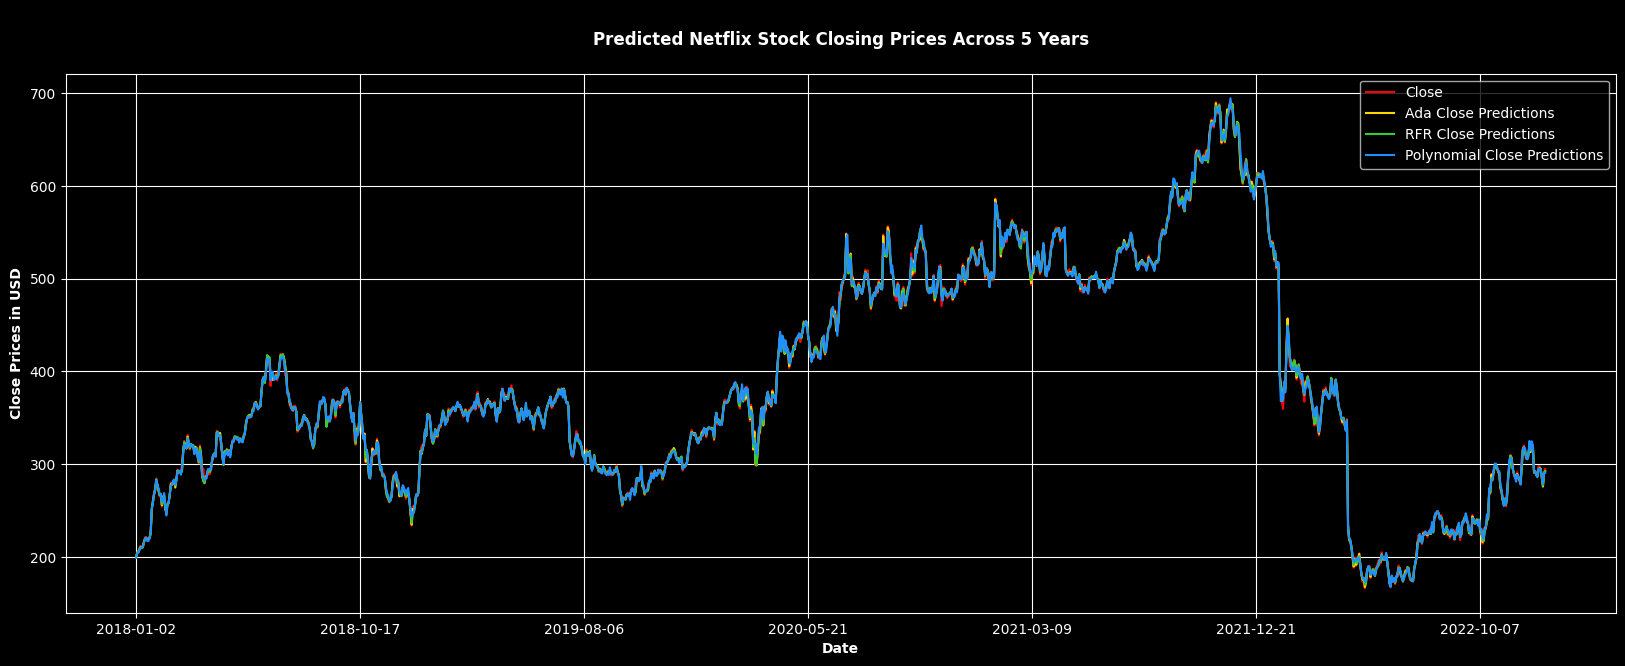

In [31]:
# Plotting all the predictions and the datasets closing prices against the index (Date)
NFLX_df["Close"].plot(color="red", figsize=(20, 7))
NFLX_df["Ada Close Predictions"].plot(color="gold")
NFLX_df["RFR Close Predictions"].plot(color="limegreen")
NFLX_df["Polynomial Close Predictions"].plot(color="dodgerblue")

plt.xlabel("Date", weight="bold")
plt.ylabel("Close Prices in USD", weight="bold")
plt.title("\nPredicted Netflix Stock Closing Prices Across 5 Years\n", weight="bold")
plt.legend()
plt.grid()
plt.show()